<a href="https://colab.research.google.com/github/angelgomes06-ops/Consumo-kWh/blob/main/Consumo_de_energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vRH7NpDdrtqjB2x_AGkpVbWYXrzJVtk21RlbeN4jMhy0HXefRNIL6k8SbRinguzLeXv4PzVkcYD4Yw3/pub?gid=0&single=true&output=csv')
df.head()
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Mês/Ano             10 non-null     object
 1   Consumo (kWh)       10 non-null     int64 
 2   Valor da conta      10 non-null     object
 3   Scooter utilizada?  10 non-null     object
dtypes: int64(1), object(3)
memory usage: 452.0+ bytes


Index(['Mês/Ano', 'Consumo (kWh)', 'Valor da conta', 'Scooter utilizada?'], dtype='object')

In [ ]:
df.head(10)


,Mês/Ano,Consumo (kWh),Valor da conta,Scooter utilizada?
0,Novembro,95,"106,39",Não
1,Dezembro,106,"115,42",Não
2,Janeiro,106,"112,37",Não
3,Fevereiro,90,"87,53",Não
4,Março,109,"109,3",Não
5,Abril,104,"110,46",Sim
6,Maio,91,"98,04",Sim
7,Junho,90,"88,72",Sim
8,Julho,89,"86,57",Sim
9,Agosto,92,"90,36",Sim


In [ ]:
df['Valor da conta'] = pd.to_numeric(df['Valor da conta'].str.replace(',', '.', regex=False))

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Mês/Ano             10 non-null     object 
 1   Consumo (kWh)       10 non-null     int64  
 2   Valor da conta      10 non-null     float64
 3   Scooter utilizada?  10 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 452.0+ bytes



Média Scooter Elétrica




In [ ]:
antes = df[df['Scooter utilizada?'] == 'Não']
depois = df[df['Scooter utilizada?'] == 'Sim']


media_antes = antes['Consumo (kWh)'].mean()
media_depois = depois['Consumo (kWh)'].mean()

print(f'Média antes:{media_antes: .2f}kWh')
print(f'Média depois:{media_depois: .2f}kWh')

df.info()

Média antes: 101.20kWh
Média depois: 93.20kWh
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Mês/Ano             10 non-null     object 
 1   Consumo (kWh)       10 non-null     int64  
 2   Valor da conta      10 non-null     float64
 3   Scooter utilizada?  10 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 452.0+ bytes


Redução em kWh e em porcentual

In [ ]:
reducao_kwh = media_antes - media_depois
reducao_percentual = (reducao_kwh / media_antes) * 100

print(f'Redução média: {reducao_kwh:.2f} kWh/mês')
print(f'Redução percentual: {reducao_percentual:.2f}%')

Redução média: 8.00 kWh/mês
Redução percentual: 7.91%


Como o consumo se comportou mês a mês.

In [ ]:
df[['Mês/Ano', 'Consumo (kWh)', 'Scooter utilizada?']]

,Mês/Ano,Consumo (kWh),Scooter utilizada?
0,Novembro,95,Não
1,Dezembro,106,Não
2,Janeiro,106,Não
3,Fevereiro,90,Não
4,Março,109,Não
5,Abril,104,Sim
6,Maio,91,Sim
7,Junho,90,Sim
8,Julho,89,Sim
9,Agosto,92,Sim


In [ ]:
maior_consumo = df.loc[df['Consumo (kWh)'].idxmax()]
print(f'Maior consumo: {maior_consumo['Consumo (kWh)']}kwh')
print(f'Mês/Ano: {maior_consumo['Mês/Ano']}')

Maior consumo: 109kwh
Mês/Ano: Março


In [ ]:
menor_consumo = df.loc[df['Consumo (kWh)'].idxmin()]
print(f'Menor consumo: {menor_consumo['Consumo (kWh)']}kwh')
print(f'Mês/Ano: {menor_consumo['Mês/Ano']}')

Menor consumo: 89kwh
Mês/Ano: Julho


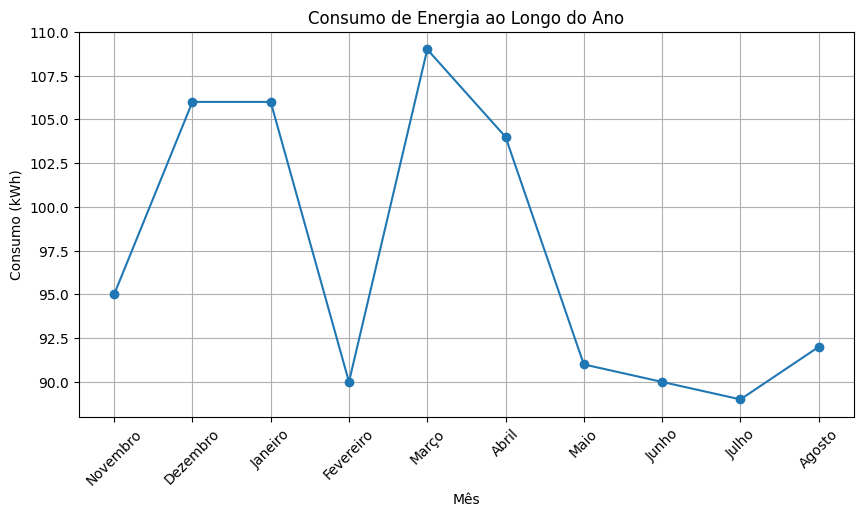

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
df['Mês/Ano'],
df['Consumo (kWh)'],
marker='o'
)

plt.title('Consumo de Energia ao Longo do Ano')
plt.xlabel('Mês')
plt.ylabel('Consumo (kWh)')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()


Média da conta

In [ ]:
media_conta_antes = antes['Valor da conta'].mean()
media_conta_depois = depois['Valor da conta'].mean()

print(f'Média da conta antes: R$ {media_conta_antes:.2f}')
print(f'Média da conta depois: R$ {media_conta_depois:.2f}')


Média da conta antes: R$ 106.20
Média da conta depois: R$ 94.83


In [ ]:
reducao_conta = media_conta_antes - media_conta_depois
reducao_conta_percentual = (reducao_conta / media_conta_antes) * 100

print(f'Redução média na conta: R$ {reducao_conta:.2f}')
print(f'Redução percentual na conta: {reducao_conta_percentual:.2f}%')

Redução média na conta: R$ 11.37
Redução percentual na conta: 10.71%


Consumo scooter por recarga

In [ ]:
potencia_scooter = 1000 / 1000  # transforma W em kW
horas_carga = 8
cargas_semana = 1
semanas_mes = 4.33

consumo_por_carga = potencia_scooter * horas_carga

consumo_mensal_scooter = (
consumo_por_carga *
cargas_semana *
semanas_mes
)

print(f'Consumo estimado por carga: {consumo_por_carga:.2f} kWh')
print(f'Consumo mensal estimado: {consumo_mensal_scooter:.2f} kWh')


Consumo estimado por carga: 8.00 kWh
Consumo mensal estimado: 34.64 kWh
